# Phân loại bệnh tim: Decision Tree, Random Forest và XGBoost


In [1]:
#Tải file heart.csv từ trên máy tính lên colab
from google.colab import files
uploaded = files.upload()
DATA_PATH = next(iter(uploaded))
print('Đã upload:', DATA_PATH)

Saving heart.csv to heart.csv
Đã upload: heart.csv


In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [3]:
df = pd.read_csv(DATA_PATH)
print('Kích thước dữ liệu:', df.shape)
df.head()

Kích thước dữ liệu: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [10]:
df.info()
print('\nSố giá trị thiếu mỗi cột:')
display(df.isna().sum())
print('\nTỷ lệ nhãn HeartDisease:')
display(df['HeartDisease'].value_counts(normalize=True).rename('Tỷ lệ'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB

Số giá trị thiếu mỗi cột:


,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0



Tỷ lệ nhãn HeartDisease:


,Tỷ lệ
HeartDisease,
1,0.553377
0,0.446623


In [11]:
# Tách X/y và chia dữ liệu: 80% train, 20% test
X = df.drop(columns='HeartDisease')
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=67, stratify=y
)
# Random_state là tham số trong hàm chia bộ test, đóng vai trò làm seed để chia ngẫu nhiên.
# Điều này đảm bảo kết quả các lần chạy lại notebook ko có sự khác nhau, đảm bảo tính ổn định.

categorical_cols = X.select_dtypes(include=['object', 'string']).columns
numeric_cols = X.select_dtypes(exclude=['object', 'string']).columns

#Quy tắc tiền xử lí dữ liệu, cột categorical thì chuyển thành các feature one-hot 1 0
#Cột nào là số sẵn thì bỏ qua ko xử lí, passthrough
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', 'passthrough', numeric_cols)
])
X_train_ready = preprocessor.fit_transform(X_train) #Tiền xử lí tập train
X_test_ready = preprocessor.transform(X_test) #Xử
feature_names = preprocessor.get_feature_names_out()

print('Train:', X_train_ready.shape, '| Test:', X_test_ready.shape)
results = {}

Train: (734, 20) | Test: (184, 20)


In [12]:
def evaluate_model(name, model):
    start = time.perf_counter()
    model.fit(X_train_ready, y_train)
    train_time = time.perf_counter() - start

    train_acc = accuracy_score(y_train, model.predict(X_train_ready))
    test_acc = accuracy_score(y_test, model.predict(X_test_ready))
    results[name] = {
        'Train accuracy': train_acc,
        'Test accuracy': test_acc,
        'Chênh lệch train-test': train_acc - test_acc,
        'Thời gian train (giây)': train_time
    }
    print(f'Train accuracy: {train_acc:.3f}')
    print(f'Test accuracy:  {test_acc:.3f}')
    print(f'Chênh lệch:     {train_acc - test_acc:.3f}')
    print(f'Thời gian train: {train_time:.3f} giây')
    return model

def plot_importance(model, title):
    importance = pd.Series(model.feature_importances_, index=feature_names)
    importance = importance.sort_values().tail(12)
    ax = importance.plot.barh(figsize=(8, 5), color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('Feature importance')
    plt.show()
    print('Feature quan trọng nhất:', importance.index[-1])

## 1. Decision Tree

Train accuracy: 1.000
Test accuracy:  0.766
Chênh lệch:     0.234
Thời gian train: 0.011 giây


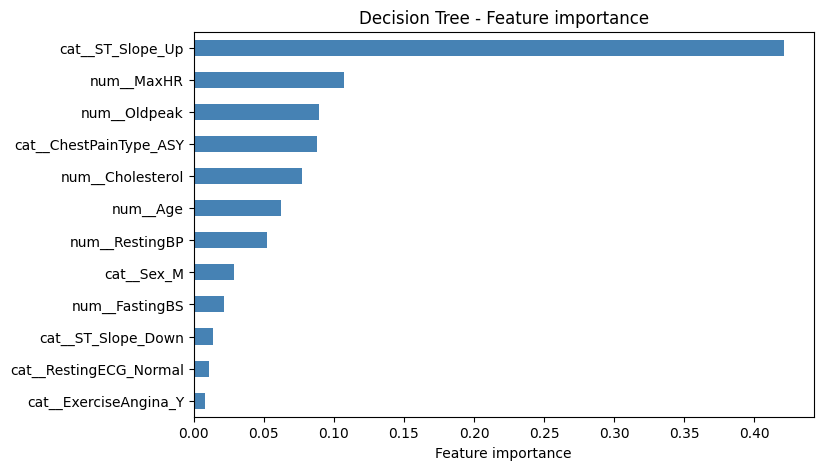

Feature quan trọng nhất: cat__ST_Slope_Up


In [13]:
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree = evaluate_model('Decision Tree', decision_tree)
plot_importance(decision_tree, 'Decision Tree - Feature importance')

## 2. Random Forest

Train accuracy: 1.000
Test accuracy:  0.902
Chênh lệch:     0.098
Thời gian train: 0.844 giây


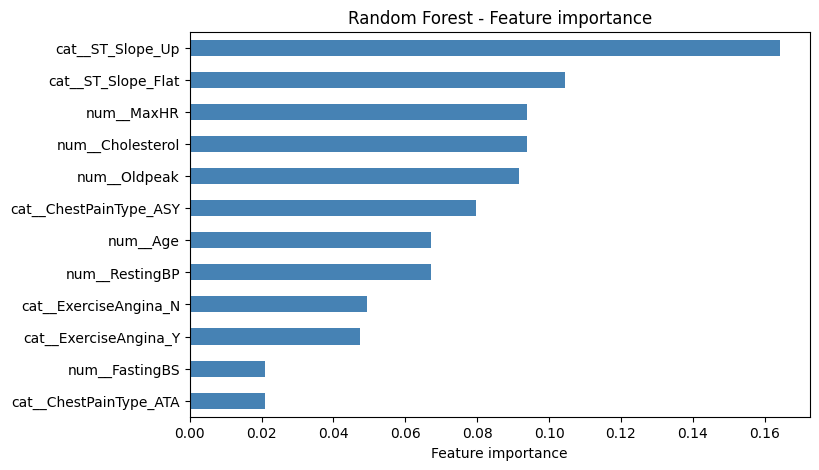

Feature quan trọng nhất: cat__ST_Slope_Up


In [7]:
random_forest = RandomForestClassifier(
    n_estimators=200, random_state=42, n_jobs=-1
)
random_forest = evaluate_model('Random Forest', random_forest)
plot_importance(random_forest, 'Random Forest - Feature importance')

## 3. XGBoost

Train accuracy: 0.935
Test accuracy:  0.886
Chênh lệch:     0.049
Thời gian train: 0.110 giây


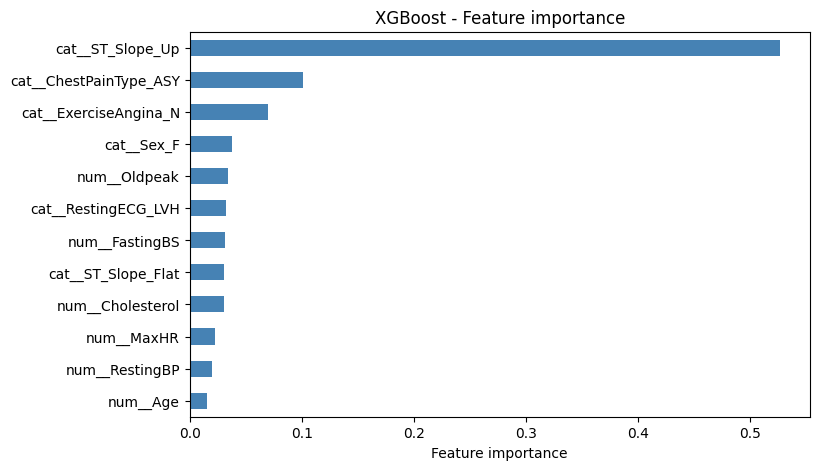

Feature quan trọng nhất: cat__ST_Slope_Up


In [8]:
xgboost = XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    random_state=42, n_jobs=-1, eval_metric='logloss'
)
xgboost = evaluate_model('XGBoost', xgboost)
plot_importance(xgboost, 'XGBoost - Feature importance')

## Bảng tổng kết và nhận xét

In [9]:
summary = pd.DataFrame(results).T
display(summary.style.format({
    'Train accuracy': '{:.3f}',
    'Test accuracy': '{:.3f}',
    'Chênh lệch train-test': '{:.3f}',
    'Thời gian train (giây)': '{:.3f}'
}))

models = {
    'Decision Tree': decision_tree,
    'Random Forest': random_forest,
    'XGBoost': xgboost
}
top_features = {
    name: feature_names[np.argmax(model.feature_importances_)]
    for name, model in models.items()
}
display(pd.Series(top_features, name='Feature quan trọng nhất'))

print('Nhận xét: test accuracy cao hơn nghĩa là dự đoán tốt hơn trên tập test.')
print('Chênh lệch train-test càng nhỏ thì mô hình càng ít có dấu hiệu overfitting.')
print('Nếu ba feature trên giống hoặc gần giống nhau, tầm quan trọng là nhất quán giữa các model.')

,Train accuracy,Test accuracy,Chênh lệch train-test,Thời gian train (giây)
Decision Tree,1.000,0.766,0.234,0.008
Random Forest,1.000,0.902,0.098,0.844
XGBoost,0.935,0.886,0.049,0.110


,Feature quan trọng nhất
Decision Tree,cat__ST_Slope_Up
Random Forest,cat__ST_Slope_Up
XGBoost,cat__ST_Slope_Up


Nhận xét: test accuracy cao hơn nghĩa là dự đoán tốt hơn trên tập test.
Chênh lệch train-test càng nhỏ thì mô hình càng ít có dấu hiệu overfitting.
Nếu ba feature trên giống hoặc gần giống nhau, tầm quan trọng là nhất quán giữa các model.
